In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")

In [3]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [4]:
df.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn import tree

In [6]:
df = pd.get_dummies(df, columns=["Gender"],drop_first = True, dtype=int)

In [7]:
df

,User ID,Age,EstimatedSalary,Purchased,Gender_Male
0,15624510,19,19000,0,1
1,15810944,35,20000,0,1
2,15668575,26,43000,0,0
3,15603246,27,57000,0,0
4,15804002,19,76000,0,1
...,...,...,...,...,...
395,15691863,46,41000,1,0
396,15706071,51,23000,1,1
397,15654296,50,20000,1,0
398,15755018,36,33000,0,1


In [8]:
x = df.drop(["User ID","Purchased"],axis=1)
y = df["Purchased"]

In [9]:
x

,Age,EstimatedSalary,Gender_Male
0,19,19000,1
1,35,20000,1
2,26,43000,0
3,27,57000,0
4,19,76000,1
...,...,...,...
395,46,41000,0
396,51,23000,1
397,50,20000,0
398,36,33000,1


In [24]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [10]:
x_train, x_test, y_train,y_test = train_test_split(
    x,y,test_size = 0.20, random_state = 42, stratify = y
)

In [20]:
model = DecisionTreeClassifier(
    criterion = 'gini', max_depth = 5, random_state = 42
)

In [21]:
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [22]:
y_test_pred = model.predict(x_test)

In [23]:
y_test_pred

array([1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0])

In [24]:
Accuracy = accuracy_score(y_test, y_test_pred) * 100

print(f"Accuracy Score: {Accuracy:.2f}%")

Accuracy Score: 82.50%


In [25]:
classification = classification_report(
    y_test,
    y_test_pred,
    target_names=["Not Purchased", "Purchased"]
)

print("Classification Report:\n", classification)

Classification Report:
                precision    recall  f1-score   support

Not Purchased       0.88      0.84      0.86        51
    Purchased       0.74      0.79      0.77        29

     accuracy                           0.82        80
    macro avg       0.81      0.82      0.81        80
 weighted avg       0.83      0.82      0.83        80



In [26]:
cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[43  8]
 [ 6 23]]


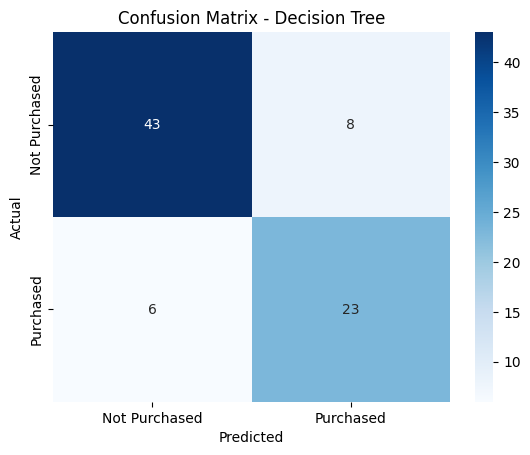

In [27]:
import seaborn as sns
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Purchased", "Purchased"],
    yticklabels=["Not Purchased", "Purchased"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

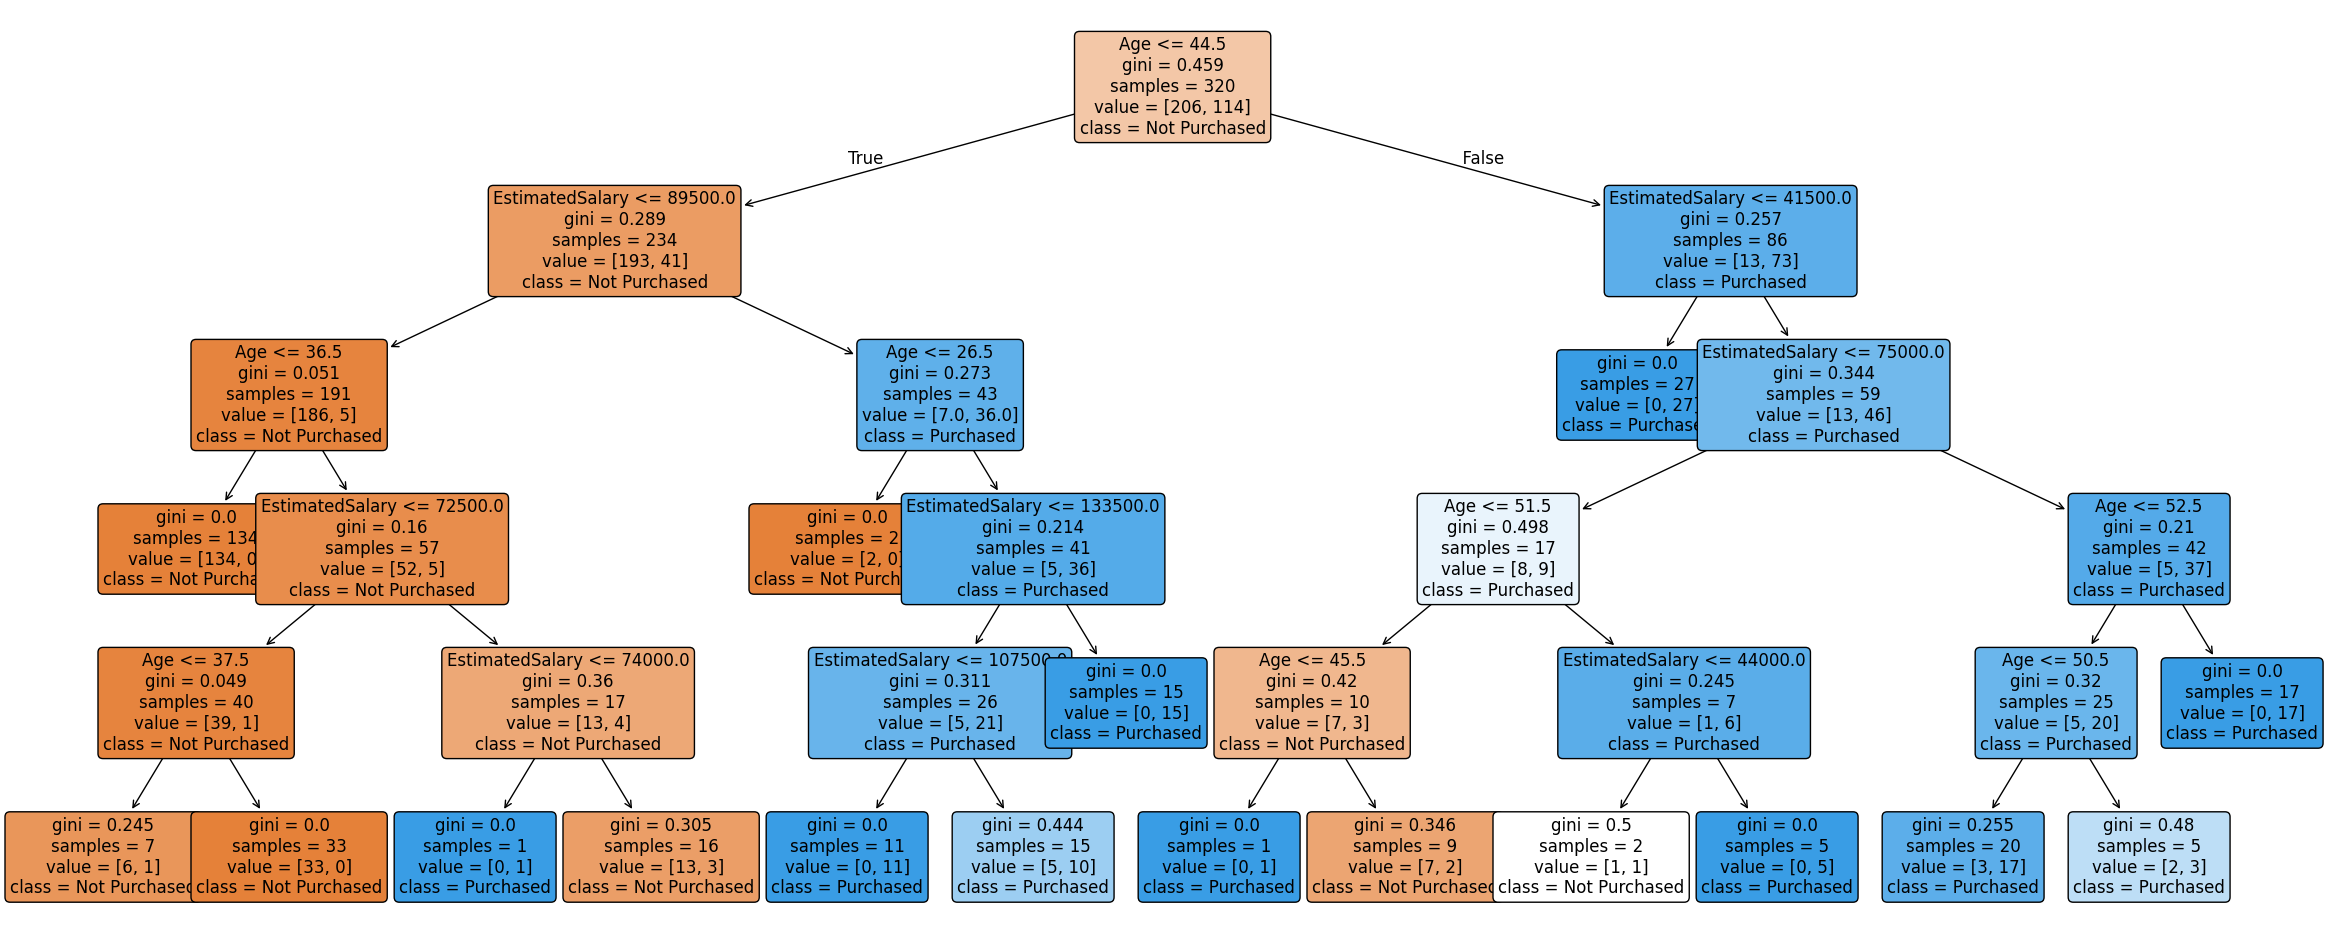

In [29]:
from sklearn.tree import plot_tree

plt.figure(figsize=(30, 12))

plot_tree(
    model,
    feature_names=x.columns,
    class_names=["Not Purchased", "Purchased"],
    filled=True,
    rounded=True,
    max_depth=5,
    fontsize = 12
)

plt.show()

### Conclusion
The Decision Tree model achieved 82.50% accuracy on the test dataset. For Not Purchased, the model achieved 88% precision and 86% F1-score, while for Purchased, it achieved 74% precision and 77% F1-score, with a 79% recall. Overall, the model provides a reliable baseline for predicting customer purchase behavior and supporting data-driven marketing decisions.